# HW 5

In [224]:
import csv
import json
import os
import re
from dataclasses import dataclass, asdict
from datetime import datetime, timedelta
from typing import List, Dict, Any, Tuple, Optional

import matplotlib.pyplot as plt
import pandas as pd

In [225]:
@dataclass(frozen=True)
class OperationRecord:
    op_type: str
    amount: float
    timestamp: datetime
    balance_after: float
    status: str
    message: str = ""

    def to_dict(self) -> Dict[str, Any]:
        d = asdict(self)
        d["timestamp"] = self.timestamp.isoformat(timespec="seconds")
        return d


In [226]:
class Account:
    _account_counter: int = 1000
    allowed_ops: Tuple[str, ...] = ("deposit", "withdraw")

    def __init__(self, account_holder: str, balance: float = 0.0) -> None:
        self._validate_holder_name(account_holder)
        if balance < 0:
            raise ValueError("Начальный баланс не может быть отрицательным.")
        self.holder = account_holder
        self.account_number = f"ACC-{Account._account_counter:04d}"
        Account._account_counter += 1
        self._balance: float = float(balance)
        self._operations_history: List[OperationRecord] = []

    def deposit(self, amount: float) -> None:
        if amount <= 0:
            raise ValueError("Сумма для пополнения должна быть положительной.")
        self._balance += float(amount)
        self._log("deposit", amount, "success", f"Пополнение на {amount:.2f} выполнено.")

    def withdraw(self, amount: float) -> bool:
        if amount <= 0:
            raise ValueError("Сумма для снятия должна быть положительной.")
        if amount > self._balance:
            self._log("withdraw", amount, "fail",
                      f"Недостаточно средств: попытка снять {amount:.2f}, доступно {self._balance:.2f}.")
            return False
        self._balance -= float(amount)
        self._log("withdraw", amount, "success", f"Снятие {amount:.2f} успешно.")
        return True

    def get_balance(self):
        return self._balance

    def get_history(self, as_dicts=True):
        return [r.to_dict() for r in self._operations_history] if as_dicts else self._operations_history

    def _log(self, op_type, amount, status, message="", ts_override=None):
        rec = OperationRecord(op_type, float(amount),
                              ts_override if ts_override else datetime.now(),
                              self._balance, status, message)
        self._operations_history.append(rec)

    @staticmethod
    def _validate_holder_name(name):
        if not isinstance(name, str):
            raise ValueError("Имя владельца должно быть строкой.")
        pattern = r"^([A-Z][a-z]+ [A-Z][a-z]+|[А-ЯЁ][а-яё]+ [А-ЯЁ][а-яё]+)$"
        if not re.match(pattern, name.strip()):
            raise ValueError("Имя должно быть в формате 'Имя Фамилия' с заглавных букв.")

    @staticmethod
    def _valid_amount(x: Optional[float]) -> bool:
        return isinstance(x, (int, float)) and x is not None and 0 < x == x

    def apply_operation_at(
            self,
            op: str,
            *,
            amount: Optional[float] = None,
            rate: Optional[float] = None,
            timestamp: Optional[datetime] = None,
    ) -> bool:
        ts = timestamp or datetime.now()

        if op == "deposit":
            if not self._valid_amount(amount):
                self._log("deposit", float(amount or 0), "fail", "Некорректная сумма для пополнения.", ts_override=ts)
                return False
            self._balance += float(amount)
            self._log("deposit", float(amount), "success", f"Пополнение на {amount:.2f} выполнено.", ts_override=ts)
            return True

        elif op == "withdraw":
            if not self._valid_amount(amount):
                self._log("withdraw", float(amount or 0), "fail", "Некорректная сумма для снятия.", ts_override=ts)
                return False
            if float(amount) > self._balance:
                self._log("withdraw", float(amount), "fail",
                          f"Недостаточно средств: попытка снять {amount:.2f}, доступно {self._balance:.2f}.",
                          ts_override=ts)
                return False
            self._balance -= float(amount)
            self._log("withdraw", float(amount), "success", f"Снятие {amount:.2f} успешно.", ts_override=ts)
            return True

        elif op == "interest":
            self._log("interest", float(amount or 0), "fail", "Операция процентов не поддерживается.", ts_override=ts)
            return False

        else:
            self._log(op, float(amount or 0), "fail", "Неизвестный тип операции.", ts_override=ts)
            return False

    @staticmethod
    def _parse_amount(v) -> Optional[float]:
        if v is None: return None
        if isinstance(v, (int, float)): return float(v)
        s = str(v).strip().replace(",", ".").replace(" ", "")
        try:
            return float(s)
        except ValueError:
            return None

    @staticmethod
    def _parse_timestamp(v) -> Optional[datetime]:
        if v is None: return None
        if isinstance(v, (int, float)):
            try:
                if v > 1e12: v = v / 1000.0  # мс → сек
                return datetime.fromtimestamp(float(v))
            except (ValueError, OSError):
                return None
        s = str(v).strip()
        try:
            return datetime.fromisoformat(s.replace(" ", "T"))
        except ValueError:
            pass
        fmts = ["%Y-%m-%d %H:%M:%S", "%Y-%m-%d %H:%M", "%Y-%m-%d",
                "%d.%m.%Y %H:%M:%S", "%d.%m.%Y %H:%M", "%d.%m.%Y",
                "%Y/%m/%d %H:%M:%S", "%Y/%m/%d %H:%M", "%Y/%m/%d"]
        for fmt in fmts:
            try:
                return datetime.strptime(s, fmt)
            except ValueError:
                continue
        return None

    @staticmethod
    def _normalize_op_type(raw: str) -> str:
        s = (raw or "").strip().lower()
        s = re.sub(r"[^a-zа-яё]", "", s)
        mapping = {
            "deposit": "deposit", "deposite": "deposit", "dep": "deposit", "topup": "deposit",
            "пополнение": "deposit", "пополнениесчета": "deposit",
            "withdraw": "withdraw", "wd": "withdraw", "cashout": "withdraw", "снятие": "withdraw",
            "interest": "interest", "intr": "interest", "проценты": "interest", "начислениепроцентов": "interest",
        }
        return mapping.get(s, (raw or "").strip().lower())

    def _read_transactions_file(self, path: str) -> list[dict]:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Файл не найден: {path}")
        ext = os.path.splitext(path)[1].lower()
        if ext == ".csv":
            out = []
            with open(path, "r", encoding="utf-8") as f:
                reader = csv.DictReader(f)
                for row in reader:
                    out.append({(k or "").strip(): v for k, v in row.items()})
            return out
        if ext == ".json":
            with open(path, "r", encoding="utf-8") as f:
                data = json.load(f)
            if isinstance(data, list): return data
            if isinstance(data, dict): return data.get("transactions", [data])
            raise ValueError("JSON должен быть объектом или массивом.")
        raise ValueError("Поддерживаются только .csv и .json")

    def clean_history(self, rows: list[dict]) -> list[dict]:
        cleaned: list[dict] = []
        for r in rows:
            op = self._normalize_op_type(r.get("type") or r.get("operation") or r.get("op"))
            if op not in getattr(self, "allowed_ops", ("deposit", "withdraw")):
                continue
            ts = self._parse_timestamp(r.get("timestamp") or r.get("date") or r.get("time"))
            if ts is None: continue

            amount = self._parse_amount(r.get("amount") or r.get("amt") or r.get("sum"))
            rate = self._parse_amount(r.get("rate")) if r.get("rate") is not None else None

            if op in ("deposit", "withdraw"):
                if amount is None or amount <= 0: continue
                cleaned.append({"type": op, "timestamp": ts, "amount": float(amount)})
            elif op == "interest":
                if amount is not None and amount > 0:
                    cleaned.append({"type": op, "timestamp": ts, "amount": float(amount)})
                elif rate is not None and rate > 0:
                    cleaned.append({"type": op, "timestamp": ts, "rate": float(rate)})
        return cleaned

    def load_history(self, path: str) -> dict:
        raw = self._read_transactions_file(path)
        summary = {"read": len(raw), "clean": 0, "applied": 0, "skipped": 0}
        cleaned = self.clean_history(raw)
        summary["clean"] = len(cleaned)
        cleaned.sort(key=lambda r: r["timestamp"])

        for tr in cleaned:
            op = tr["type"]
            ts = tr["timestamp"]
            ok = False
            if op in ("deposit", "withdraw"):
                ok = self.apply_operation_at(op, amount=tr["amount"], timestamp=ts)
            elif op == "interest":
                ok = (self.apply_operation_at(op, amount=tr["amount"], timestamp=ts)
                      if "amount" in tr else
                      self.apply_operation_at(op, rate=tr.get("rate"), timestamp=ts))
            summary["applied" if ok else "skipped"] += 1
        return summary

In [227]:
class CheckingAccount(Account):
    account_type = "checking"
    allowed_ops: Tuple[str, ...] = ("deposit", "withdraw")

In [228]:
class SavingsAccount(Account):
    account_type = "savings"
    allowed_ops: Tuple[str, ...] = ("deposit", "withdraw", "interest")

    def apply_operation_at(
            self,
            op: str,
            *,
            amount: Optional[float] = None,
            rate: Optional[float] = None,
            timestamp: Optional[datetime] = None,
    ) -> bool:
        ts = timestamp or datetime.now()

        if op == "withdraw":
            if not self._valid_amount(amount):
                self._log("withdraw", float(amount or 0), "fail", "Некорректная сумма для снятия.", ts_override=ts)
                return False
            limit = 0.5 * self._balance
            if float(amount) > limit:
                self._log("withdraw", float(amount), "fail",
                          f"Нельзя снять более 50% от баланса. Лимит: {limit:.2f}.", ts_override=ts)
                return False
            return super().apply_operation_at("withdraw", amount=float(amount), timestamp=ts)

        if op == "interest":
            if not isinstance(rate, (int, float)) or rate <= 0:
                self._log("interest", 0.0, "fail", "Некорректная ставка процента.", ts_override=ts)
                return False
            base = self._balance
            interest = base * (float(rate) / 100.0)
            self._balance += interest
            self._log("interest", float(interest), "success",
                      f"Начислены проценты {float(rate):.2f}% на {base:.2f} → +{interest:.2f}.",
                      ts_override=ts)
            return True

        return super().apply_operation_at(op, amount=amount, rate=rate, timestamp=ts)

In [229]:
def plot_history(account, annotate=True):
    hist = account.get_history(True)
    if not hist:
        print("Нет данных для визуализации.")
        return
    df = pd.DataFrame(hist)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)

    plt.figure()
    plt.step(df["timestamp"], df["balance_after"], where="post", label="Баланс")
    for op_type, marker in [("deposit", "o"), ("withdraw", "s"), ("interest", "^")]:
        sub = df[(df["op_type"] == op_type) & (df["status"] == "success")]
        if not sub.empty:
            plt.scatter(sub["timestamp"], sub["balance_after"], label=op_type, marker=marker)
    fails = df[df["status"] == "fail"]
    if not fails.empty:
        plt.scatter(fails["timestamp"], fails["balance_after"], marker="x", label="fail")

    plt.title(f"История баланса: {account.account_number} ({account.holder}) — итог {account.get_balance():.2f}")
    plt.xlabel("Время операции")
    plt.ylabel("Баланс после операции")
    plt.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()

    if annotate and not df.empty:
        plt.annotate(f"{df.iloc[0]['balance_after']:.0f}", (df.iloc[0]["timestamp"], df.iloc[0]["balance_after"]),
                     xytext=(5, 5), textcoords="offset points")
        plt.annotate(f"{df.iloc[-1]['balance_after']:.0f}", (df.iloc[-1]["timestamp"], df.iloc[-1]["balance_after"]),
                     xytext=(5, 5), textcoords="offset points")


In [230]:
def apply_demo_scenario(account, start_date="2024-01-01"):
    t0 = datetime.fromisoformat(start_date)
    step = timedelta(days=21)

    rows = [
        {"type": "deposit", "amount": -1, "timestamp": t0 + step * 0},  # проверка fail по некорректной сумме пополнения
        {"type": "deposit", "amount": 1000, "timestamp": t0 + step * 1},
        {"type": "deposit", "amount": 300, "timestamp": t0 + step * 2},
        {"type": "withdraw", "amount": -1, "timestamp": t0 + step * 3},
        {"type": "withdraw", "amount": 200, "timestamp": t0 + step * 4},  # проверка fail по некорректной сумме снятия
        {"type": "withdraw", "amount": 5000, "timestamp": t0 + step * 5},  # проверка fail по средствам
    ]

    if getattr(account, "account_type", "") == "savings":
        rows += [
            {"type": "withdraw", "amount": 551, "timestamp": t0 + step * 6},  # проверка fail по 50%
            {"type": "interest", "rate": 5, "timestamp": t0 + step * 7},  # проценты по ставке
            {"type": "interest", "rate": -5, "timestamp": t0 + step * 8},  # проверка fail по некорректной ставке
        ]
    else:
        rows += [
            {"type": "deposit", "amount": 700, "timestamp": t0 + step * 6},
            {"type": "deposit", "amount": 700, "timestamp": t0 + step * 7},
            {"type": "withdraw", "amount": 400, "timestamp": t0 + step * 8},
        ]

    rows += [
        {"type": "deposit", "amount": 450, "timestamp": t0 + step * 9},
        {"type": "withdraw", "amount": 250, "timestamp": t0 + step * 10},
    ]

    rows.sort(key=lambda r: r["timestamp"])

    for tr in rows:
        op = tr["type"]
        ts = tr["timestamp"]
        if op in ("deposit", "withdraw"):
            account.apply_operation_at(op, amount=tr["amount"], timestamp=ts)
        elif op == "interest":
            account.apply_operation_at(op, rate=tr.get("rate"), timestamp=ts)
        else:
            account.apply_operation_at(op, amount=tr.get("amount"), timestamp=ts)

In [231]:
def print_account_summary(account, top_n=5):
    df = pd.DataFrame(account.get_history())
    if df.empty:
        print(f"{account.account_type.capitalize()}Account {account.account_number} — {account.holder}")
        print("История операций пуста.\n")
        return

    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)

    success, fail = (df["status"] == "success").sum(), (df["status"] == "fail").sum()
    print("=" * 100)
    print(f"{account.account_type.capitalize()}Account {account.account_number} — {account.holder}")
    print(f"Текущий баланс: {account.get_balance():.2f}")
    print(f"Операций: {len(df)}, успешных: {success}, неуспешных: {fail}\n")

    print("Распределение по типам и статусам:")
    print(df.groupby(['op_type', 'status']).size().unstack(fill_value=0))
    print("\n")

    big = df.sort_values("amount", key=lambda s: s.abs(), ascending=False).head(top_n)
    print(f"Крупные операции (топ {top_n}):")
    print(big[["timestamp", "op_type", "amount", "status", "balance_after"]].to_string(index=False))
    print("\n")

    print("Хронология всех операций:")
    hist_cols = ["timestamp", "op_type", "amount", "status", "balance_after", "message"]
    df_formatted = df[hist_cols].copy()
    df_formatted["timestamp"] = df_formatted["timestamp"].dt.strftime("%Y-%m-%d %H:%M")
    print(df_formatted.to_string(index=False))
    print("=" * 100, "\n")


## Демонстрация: Валидация имени

In [232]:
CheckingAccount("IvanPetrov", 0)

ValueError: Имя должно быть в формате 'Имя Фамилия' с заглавных букв.

## Демонстрация: Валидация баланса

In [233]:
CheckingAccount("Ivan Petrov", -1)

ValueError: Начальный баланс не может быть отрицательным.

## Демонстрация: CheckingAccount

CheckingAccount ACC-1000 — Ivan Petrov
Текущий баланс: 2300.00
Операций: 11, успешных: 8, неуспешных: 3

Распределение по типам и статусам:
status    fail  success
op_type                
deposit      1        5
withdraw     2        3


Крупные операции (топ 5):
 timestamp  op_type  amount  status  balance_after
2024-04-15 withdraw  5000.0    fail         1100.0
2024-01-22  deposit  1000.0 success         1000.0
2024-05-06  deposit   700.0 success         1800.0
2024-05-27  deposit   700.0 success         2500.0
2024-07-08  deposit   450.0 success         2550.0


Хронология всех операций:
       timestamp  op_type  amount  status  balance_after                                                        message
2024-01-01 00:00  deposit    -1.0    fail            0.0                             Некорректная сумма для пополнения.
2024-01-22 00:00  deposit  1000.0 success         1000.0                               Пополнение на 1000.00 выполнено.
2024-02-12 00:00  deposit   300.0 success 

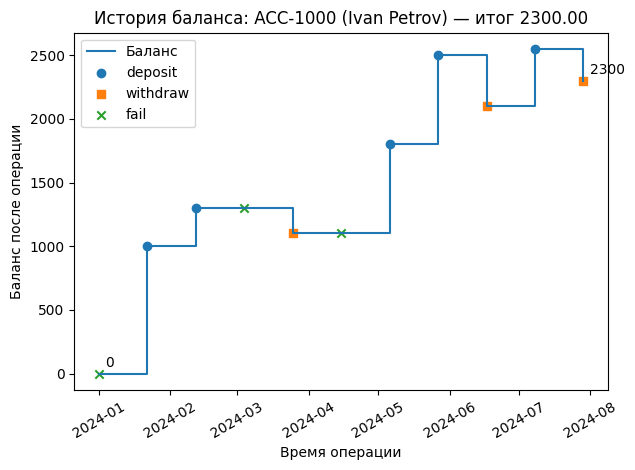

In [234]:
ca_demo = CheckingAccount("Ivan Petrov", 0)
apply_demo_scenario(ca_demo, start_date="2024-01-01")
print_account_summary(ca_demo)
plot_history(ca_demo, annotate=True)

## Демонстрация: SavingsAccount

SavingsAccount ACC-1001 — Иван Петров
Текущий баланс: 1355.00
Операций: 11, успешных: 6, неуспешных: 5

Распределение по типам и статусам:
status    fail  success
op_type                
deposit      1        3
interest     1        1
withdraw     3        2


Крупные операции (топ 5):
 timestamp  op_type  amount  status  balance_after
2024-04-15 withdraw  5000.0    fail         1100.0
2024-01-22  deposit  1000.0 success         1000.0
2024-05-06 withdraw   551.0    fail         1100.0
2024-07-08  deposit   450.0 success         1605.0
2024-02-12  deposit   300.0 success         1300.0


Хронология всех операций:
       timestamp  op_type  amount  status  balance_after                                           message
2024-01-01 00:00  deposit    -1.0    fail            0.0                Некорректная сумма для пополнения.
2024-01-22 00:00  deposit  1000.0 success         1000.0                  Пополнение на 1000.00 выполнено.
2024-02-12 00:00  deposit   300.0 success         1300.0  

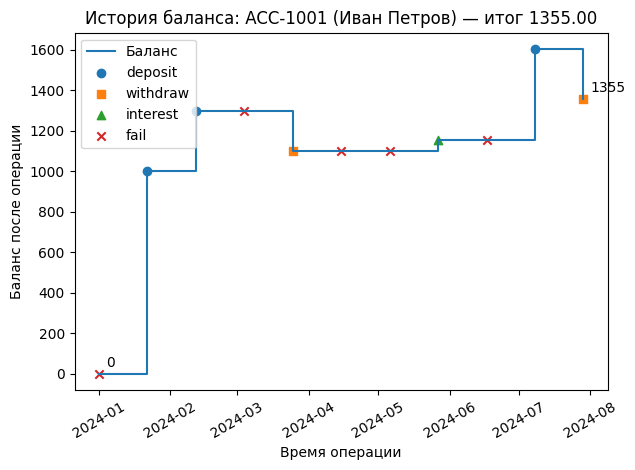

In [235]:
sa_demo = SavingsAccount("Иван Петров", 0)
apply_demo_scenario(sa_demo, start_date="2024-01-01")
print_account_summary(sa_demo)
plot_history(sa_demo, annotate=True)

## Демонстрация: загрузка из csv&json

In [236]:
CSV_PATH = "/home/jovyan/work/HW_5/data/transactions_dirty.csv"
JSON_PATH = "/home/jovyan/work/HW_5/data/transactions_dirty.json"

ca = CheckingAccount("Ivan Petrov", 0)
try:
    print("CSV summary:", ca.load_history(CSV_PATH))
except FileNotFoundError as e:
    print(e)

sa = SavingsAccount("Иван Петров", 0)
try:
    print("JSON summary:", sa.load_history(JSON_PATH))
except FileNotFoundError as e:
    print(e)

print("CA balance:", ca.get_balance(), "ops:", len(ca.get_history()))
print("SA balance:", sa.get_balance(), "ops:", len(sa.get_history()))

CSV summary: {'read': 105, 'clean': 64, 'applied': 64, 'skipped': 0}
JSON summary: {'read': 105, 'clean': 76, 'applied': 63, 'skipped': 13}
CA balance: 16615.0 ops: 64
SA balance: 17056.0 ops: 76


In [237]:
sa.get_history()

[{'op_type': 'deposit',
  'amount': 192.0,
  'timestamp': '2025-09-23T22:17:26',
  'balance_after': 192.0,
  'status': 'success',
  'message': 'Пополнение на 192.00 выполнено.'},
 {'op_type': 'deposit',
  'amount': 662.0,
  'timestamp': '2025-09-23T22:17:26',
  'balance_after': 854.0,
  'status': 'success',
  'message': 'Пополнение на 662.00 выполнено.'},
 {'op_type': 'withdraw',
  'amount': 441.0,
  'timestamp': '2025-09-24T22:17:26',
  'balance_after': 854.0,
  'status': 'fail',
  'message': 'Нельзя снять более 50% от баланса. Лимит: 427.00.'},
 {'op_type': 'deposit',
  'amount': 649.0,
  'timestamp': '2025-09-24T22:17:26',
  'balance_after': 1503.0,
  'status': 'success',
  'message': 'Пополнение на 649.00 выполнено.'},
 {'op_type': 'deposit',
  'amount': 276.0,
  'timestamp': '2025-09-25T22:17:26',
  'balance_after': 1779.0,
  'status': 'success',
  'message': 'Пополнение на 276.00 выполнено.'},
 {'op_type': 'deposit',
  'amount': 126.0,
  'timestamp': '2025-09-25T22:17:26',
  'bal